# Part 4 — Parameter Sensitivity Experiments


## Aim of Part 4

The aim is to test how rescue behaviour changes when key parameters are varied.

The parameters explored here are:

- `alpha`: diffusion strength across the graph
- `beta`: signal decay rate
- `corrected_fraction`: fraction of nuclei acting as signal sources
- `rescue_threshold`: signal level required for rescue

This is will help identify which assumptions are most responsible for that outcome.

## Intuition from Part 3

In Part 3, nuclear positions determined graph connectivity. Once the graph was built, signal propagation followed the same Laplacian diffusion update from Part 2.

The remaining uncertainty is parameter-driven:

- If diffusion is too weak, signal remains near corrected nuclei.
- If decay is too strong, signal disappears before reaching distant nuclei.
- If the corrected fraction is too low, the source field may be insufficient for rescue.
- If the threshold is too high, signal may spread but still fail to produce rescue.

Part 4 makes these assumptions visible by running controlled sweeps.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

## Core simulation functions

The model below keeps the same conceptual structure as Part 3:

```text
positions → adjacency matrix → Laplacian → diffusion simulation → rescue outcome
```

In [15]:
def generate_positions(n_nodes=40, length=1.0, seed=7):
    """Generate irregular one-dimensional nuclear positions along a fibre."""
    rng = np.random.default_rng(seed)
    positions = np.sort(rng.uniform(0.0, length, size=n_nodes))
    return positions


def build_distance_adjacency(positions, interaction_radius=0.12):
    """Create an unweighted adjacency matrix from spatial proximity."""
    n_nodes = len(positions)
    A = np.zeros((n_nodes, n_nodes), dtype=float)

    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            distance = abs(positions[i] - positions[j])
            if distance <= interaction_radius:
                A[i, j] = 1.0
                A[j, i] = 1.0

    return A


def graph_laplacian(A):
    """Construct the combinatorial graph Laplacian L = D - A."""
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    return D - A


def choose_corrected_nuclei(n_nodes, corrected_fraction=0.1, placement="clustered", seed=7):
    """Select corrected nuclei using either clustered or distributed placement."""
    rng = np.random.default_rng(seed)
    n_corrected = max(1, round(n_nodes * corrected_fraction))

    corrected = np.zeros(n_nodes, dtype=bool)

    if placement == "clustered":
        corrected[:n_corrected] = True
    elif placement == "distributed":
        chosen = rng.choice(n_nodes, size=n_corrected, replace=False)
        corrected[chosen] = True
    else:
        raise ValueError("placement must be 'clustered' or 'distributed'")

    return corrected

## Diffusion-rescue simulation

Corrected nuclei act as source nodes. At each timestep, the signal field is updated using:

$$
u_{t+1} = u_t + dt\left(-\alpha L u_t - \beta u_t + q\right)
$$

where:

- $-\alpha L u_t$ spreads signal across graph edges
- $-\beta u_t$ removes signal through decay
- $q$ injects signal from corrected nuclei
- $dt$ controls the timestep size

Rescue is still modelled with an instantaneous threshold:

$$
r_i =
\begin{cases}
1, & \text{if } u_i > \tau \\
0, & \text{if } u_i \leq \tau
\end{cases}
$$

where:

- $r_i$ is the rescue state of nucleus $i$
- $u_i$ is the signal level at nucleus $i$
- $\tau$ is the rescue threshold

This is deliberately kept simple so that the focus of this part remains parameter sensitivity.

In [16]:
def simulate_rescue(
    positions,
    interaction_radius=0.12,
    corrected_fraction=0.1,
    placement="clustered",
    alpha=0.08,
    beta=0.03,
    production_rate=0.08,
    rescue_threshold=1.0,
    dt=0.1,
    steps=300,
    seed=7,
):
    """Run graph-based diffusion and return final signal and rescue outcomes."""
    n_nodes = len(positions)
    A = build_distance_adjacency(positions, interaction_radius=interaction_radius)
    L = graph_laplacian(A)
    corrected = choose_corrected_nuclei(
        n_nodes,
        corrected_fraction=corrected_fraction,
        placement=placement,
        seed=seed,
    )

    signal = np.zeros(n_nodes, dtype=float)
    rescued = np.zeros(n_nodes, dtype=bool)
    source = np.where(corrected, production_rate, 0.0)
    history = [signal.copy()]

    for _ in range(steps):
        signal = signal + dt * (-alpha * (L @ signal) - beta * signal + source)
        signal = np.maximum(signal, 0.0)
        rescued = rescued | (signal >= rescue_threshold)
        history.append(signal.copy())

    return {
        "positions": positions,
        "A": A,
        "L": L,
        "signal": signal,
        "rescued": rescued,
        "corrected": corrected,
        "history": np.array(history),
        "rescued_fraction": rescued.mean(),
        "max_signal": signal.max(),
    }

## Baseline run

Before sweeping parameters, I first run a baseline simulation to have a reference point fro latter results.

In [17]:
positions = generate_positions(n_nodes=40, seed=11)

baseline = simulate_rescue(
    positions,
    interaction_radius=0.12,
    corrected_fraction=0.1,
    placement="clustered",
    alpha=0.08,
    beta=0.03,
    production_rate=0.08,
    rescue_threshold=1.0,
    steps=300,
    seed=11,
)

baseline["rescued_fraction"], baseline["max_signal"]

(np.float64(0.0), np.float64(0.515139205227162))

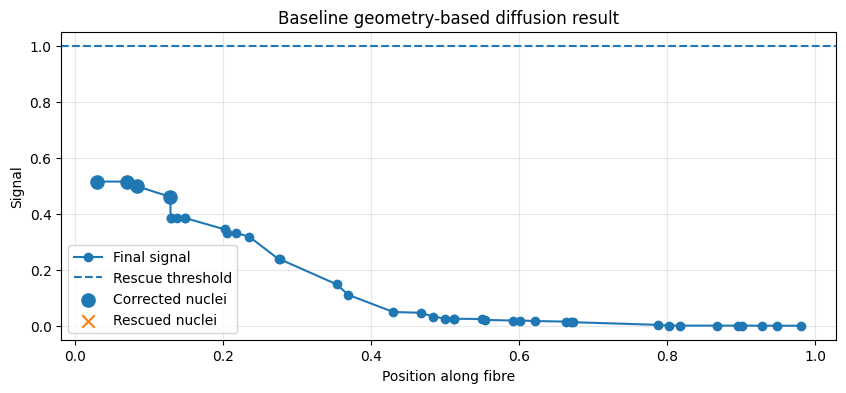

In [18]:
def plot_signal_profile(result, title="Final signal profile"):
    positions = result["positions"]
    signal = result["signal"]
    corrected = result["corrected"]
    rescued = result["rescued"]

    plt.figure(figsize=(10, 4))
    plt.plot(positions, signal, marker="o", label="Final signal")
    plt.axhline(1.0, linestyle="--", label="Rescue threshold")
    plt.scatter(positions[corrected], signal[corrected], s=90, label="Corrected nuclei")
    plt.scatter(positions[rescued], signal[rescued], s=80, marker="x", label="Rescued nuclei")
    plt.xlabel("Position along fibre")
    plt.ylabel("Signal")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_signal_profile(baseline, title="Baseline geometry-based diffusion result")

### Baseline interpretation

- The baseline run provides a reference signal profile under one fixed parameter set.
- The exact rescued fraction is less important than having a comparison point for later sweeps.
- Each parameter sweep can now be interpreted relative to this baseline.

## Sweep 1 — Diffusion strength

The first sweep varies $\alpha$, the diffusion strength.

### Biological intuition

- Low $\alpha$ means signal remains close to corrected nuclei.
- High $\alpha$ means signal spreads more effectively across the graph.
- Very high transport may smooth signal too much, depending on decay and production.


In [19]:
def sweep_alpha(positions, alpha_values):
    records = []
    for alpha in alpha_values:
        result = simulate_rescue(
            positions,
            interaction_radius=0.12,
            corrected_fraction=0.1,
            placement="clustered",
            alpha=alpha,
            beta=0.03,
            production_rate=0.08,
            rescue_threshold=1.0,
            steps=300,
            seed=11,
        )
        records.append((alpha, result["rescued_fraction"], result["max_signal"]))
    return np.array(records)


alpha_values = np.linspace(0.01, 0.20, 15)
alpha_results = sweep_alpha(positions, alpha_values)
alpha_results[:5]

array([[0.01      , 0.05      , 1.01566128],
       [0.02357143, 0.        , 0.76259635],
       [0.03714286, 0.        , 0.65352403],
       [0.05071429, 0.        , 0.59120715],
       [0.06428571, 0.        , 0.5496771 ]])

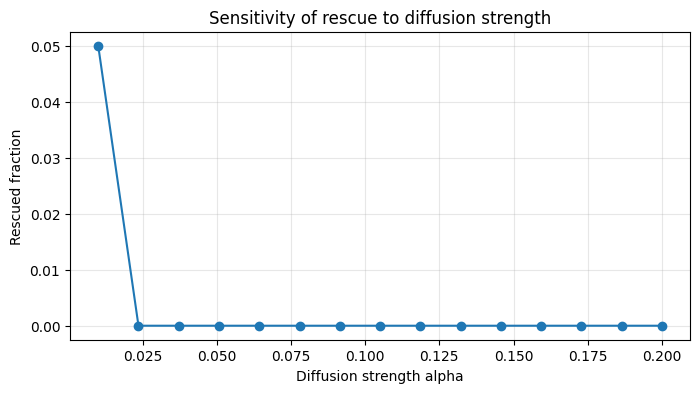

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(alpha_results[:, 0], alpha_results[:, 1], marker="o")
plt.xlabel("Diffusion strength alpha")
plt.ylabel("Rescued fraction")
plt.title("Sensitivity of rescue to diffusion strength")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation of diffusion-strength sweep

- Increasing $\alpha$ generally increases the spatial reach of signal.
- If rescue remains limited despite higher $\alpha$, the limiting factor is likely decay, production, or threshold.
- This sweep tests whether cross-correction is transport-limited.


## Sweep 2 — Decay rate

The second sweep varies $\beta$, the signal decay rate.

### Biological intuition

- Low $\beta$ allows signal to persist long enough to influence distant nuclei.
- High $\beta$ removes signal before it can spread far.
- Decay can impose a biological range limit on cross-correction.

In [21]:
def sweep_beta(positions, beta_values):
    records = []
    for beta in beta_values:
        result = simulate_rescue(
            positions,
            interaction_radius=0.12,
            corrected_fraction=0.1,
            placement="clustered",
            alpha=0.08,
            beta=beta,
            production_rate=0.08,
            rescue_threshold=1.0,
            steps=300,
            seed=11,
        )
        records.append((beta, result["rescued_fraction"], result["max_signal"]))
    return np.array(records)


beta_values = np.linspace(0.005, 0.12, 15)
beta_results = sweep_beta(positions, beta_values)
beta_results[:5]

array([[0.005     , 0.        , 0.67612483],
       [0.01321429, 0.        , 0.61505245],
       [0.02142857, 0.        , 0.56245366],
       [0.02964286, 0.        , 0.51697325],
       [0.03785714, 0.        , 0.47748844]])

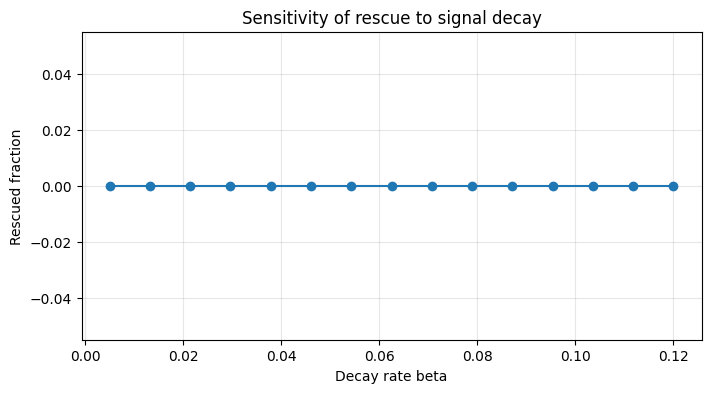

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(beta_results[:, 0], beta_results[:, 1], marker="o")
plt.xlabel("Decay rate beta")
plt.ylabel("Rescued fraction")
plt.title("Sensitivity of rescue to signal decay")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation of decay sweep

- Higher $\beta$ should reduce rescued fraction because signal is removed more quickly.
- If rescue is highly sensitive to $\beta$, signal persistence is a dominant model assumption.
- This helps distinguish weak transport from insufficient signal lifetime.

## Sweep 3 — Corrected fraction

The third sweep varies the corrected fraction, denoted $f_c$.

### Biological intuition

- Larger $f_c$ means more nuclei act as signal sources.
- More source nodes increase the total signal introduced into the fibre.
- Source placement matters because diffusion is local.


In [23]:
def sweep_corrected_fraction(positions, corrected_values, placement):
    records = []
    for corrected_fraction in corrected_values:
        result = simulate_rescue(
            positions,
            interaction_radius=0.12,
            corrected_fraction=corrected_fraction,
            placement=placement,
            alpha=0.08,
            beta=0.03,
            production_rate=0.08,
            rescue_threshold=1.0,
            steps=300,
            seed=11,
        )
        records.append((corrected_fraction, result["rescued_fraction"], result["max_signal"]))
    return np.array(records)


corrected_values = np.linspace(0.05, 0.35, 7)
clustered_results = sweep_corrected_fraction(positions, corrected_values, placement="clustered")
distributed_results = sweep_corrected_fraction(positions, corrected_values, placement="distributed")

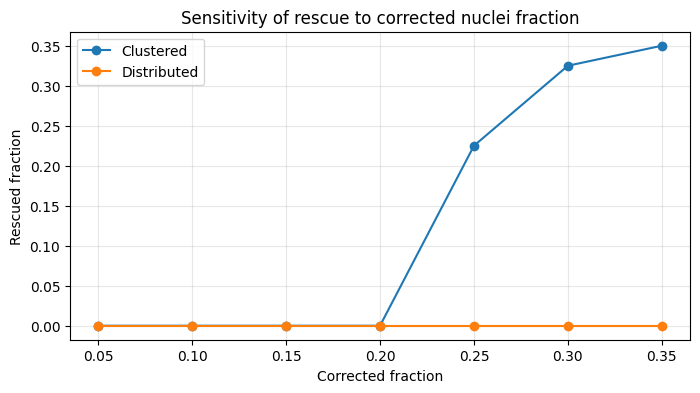

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(clustered_results[:, 0], clustered_results[:, 1], marker="o", label="Clustered")
plt.plot(distributed_results[:, 0], distributed_results[:, 1], marker="o", label="Distributed")
plt.xlabel("Corrected fraction")
plt.ylabel("Rescued fraction")
plt.title("Sensitivity of rescue to corrected nuclei fraction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation of corrected-fraction sweep

- Increasing $f_c$ should increase the rescued fraction.
- Comparing clustered and distributed placement tests whether rescue is limited by source quantity or source location.
- If distributed placement performs better, spatial coverage may matter more than local source intensity.

## Sweep 4 — Rescue threshold

The final sweep varies the rescue threshold, denoted $\tau$.

### Biological intuition

- Lower $\tau$ represents easier functional rescue.
- Higher $\tau$ requires stronger or more persistent signal.
- This parameter controls how continuous signal becomes a binary rescue outcome.

In [25]:
def sweep_threshold(positions, threshold_values):
    records = []
    for threshold in threshold_values:
        result = simulate_rescue(
            positions,
            interaction_radius=0.12,
            corrected_fraction=0.1,
            placement="clustered",
            alpha=0.08,
            beta=0.03,
            production_rate=0.08,
            rescue_threshold=threshold,
            steps=300,
            seed=11,
        )
        records.append((threshold, result["rescued_fraction"], result["max_signal"]))
    return np.array(records)


threshold_values = np.linspace(0.4, 1.6, 13)
threshold_results = sweep_threshold(positions, threshold_values)

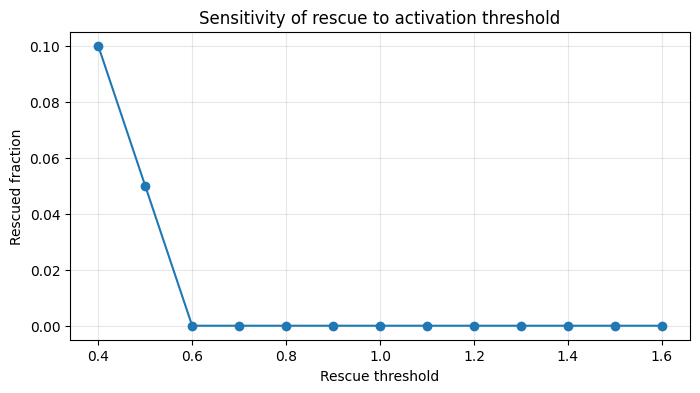

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_results[:, 0], threshold_results[:, 1], marker="o")
plt.xlabel("Rescue threshold")
plt.ylabel("Rescued fraction")
plt.title("Sensitivity of rescue to activation threshold")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation of threshold sweep

- Increasing $\tau$ should reduce the rescued fraction.
- This shows that transport and rescue are separate model layers.
- Threshold sensitivity motivates replacing instantaneous rescue with cumulative exposure in the next part.


## Summary of Part 4

Part 4 turns the geometry-based model into a hypothesis-testing tool.

The main modelling insight is that rescue depends jointly on:

- diffusion strength, $\alpha$
- decay rate, $\beta$
- corrected fraction, $f_c$
- rescue threshold, $\tau$

These sweeps help identify which assumptions are worth improving next.

## Limitations and next step

The current model still uses instantaneous rescue:

$$
r_i =
\begin{cases}
1, & \text{if } u_i > \tau \\
0, & \text{if } u_i \leq \tau
\end{cases}
$$

This is probably too abrupt for a biological correction process.

The next part should introduce cumulative exposure, where rescue depends on sustained signal over time rather than a single concentration spike.